# Airline Route Segmentation with K-Means (Route Clustering)

This notebook performs **route-level clustering** using the **K-Means** algorithm to discover groups of airline routes with similar operational behavior.

Instead of clustering individual flights, we first **aggregate flights into routes** (each route is defined by `ORIGIN_AIRPORT → DESTINATION_AIRPORT`) and compute summary metrics per route. Then we cluster those routes based on:

- **Average departure delay** (`avg_delay`) → typical punctuality of the route
- **Average distance** (`avg_distance`) → short/medium/long-haul behavior
- **Flight frequency** (`flight_count`, transformed into `log_frequency`) → demand/volume pattern

## What you will get at the end
- An automatically chosen number of clusters (**OPTIMAL_K**) using:
  - **Inertia** (Elbow)
  - **Silhouette score**
  - **Stability** via **ARI (Adjusted Rand Index)** across multiple random seeds
- Cluster labels assigned to each route
- Visual diagnostics (heatmap + scatter plots + 3D overview)
- A lightweight business-style **Executive Summary** per cluster
- Exported file: `data/clustered_routes.csv`

## 1. Libraries and Environment Setup

We import the required Python libraries for:

- **Data manipulation:** `pandas`, `numpy`
- **Visualization:** `matplotlib`, `seaborn`
- **Clustering and preprocessing:** `StandardScaler`, `KMeans`
- **Model evaluation:** `silhouette_score`, `adjusted_rand_score`
- **Automation/utility:** a reusable `KMeansKEvaluator` class (to evaluate candidate values of *k*)

### Why this matters
K-Means is sensitive to feature scale and random initialization. A clean setup with:
- consistent plotting style,
- controlled randomness,
- and reproducible evaluation
helps ensure that our conclusions are trustworthy and repeatable.

In [1]:
# ==============================================================================
# MASTER NOTEBOOK: AIRLINE ROUTE CLUSTERING ANALYSIS
# ==============================================================================
# Author: Guilherme F Dellatin
# Objective: Segment airline routes to identify operational patterns using K-Means.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from modules.kmeans_k_evaluator import KMeansKEvaluator
import warnings

# Configuration for cleaner output
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_context("notebook", font_scale=1.1)

## 2. Data Loading and Preprocessing

We load only the columns required for route clustering:

- `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT` → route definition
- `DEPARTURE_DELAY` → operational delay metric
- `DISTANCE` → route length
- `CANCELLED`, `DIVERTED` → to filter out non-standard operations

### 2.1 Cleaning rules applied
1. **Remove canceled flights** (`CANCELLED == 0`)
2. **Remove diverted flights** (`DIVERTED == 0`)
3. **Drop missing departure delays** (`DEPARTURE_DELAY` is NaN)

### Why we remove canceled/diverted flights
Canceled and diverted flights can distort route delay statistics because:
- cancellations do not represent “delay” in a meaningful way,
- diversions change the operational reality of the route,
- including them can bias averages and mislead the clustering.

By filtering them out, we keep a cleaner signal of **typical route performance**.

In [2]:
# ==============================================================================
# 2. DATA LOADING & PREPROCESSING
# ==============================================================================
print("Loading dataset...")
cols = ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT','DEPARTURE_DELAY', 'DISTANCE','CANCELLED', 'DIVERTED']
# Assuming standard file path (adjust as necessary)
df = pd.read_csv('data/flights.csv', usecols=cols, low_memory=False)
#df = pd.read_csv('flights.csv', usecols=['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
#                                         'DEPARTURE_DELAY', 'DISTANCE',
#                                         'CANCELLED', 'DIVERTED'])

print(f"Original shape: {df.shape}")

# 2.1 Charge valid airports
print("Loading valid airport codes...")
df_airports = pd.read_csv('data/airports.csv')
valid_codes = set(df_airports['IATA_CODE'].dropna())
print(f"Valid IATA codes loaded: {len(valid_codes)}")

# 2.2 Clean Data
# Remove canceled or diverted flights
df_clean = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)]
df_clean = df_clean.dropna(subset=['DEPARTURE_DELAY'])

# 2.3 Filtering only valid IATA code
df_clean = df_clean[
    df_clean['ORIGIN_AIRPORT'].isin(valid_codes) &
    df_clean['DESTINATION_AIRPORT'].isin(valid_codes)
]

print(f"Shape post validation against airports.csv: {df_clean.shape}")

Loading dataset...
Original shape: (5819079, 6)
Loading valid airport codes...
Valid IATA codes loaded: 322
Shape post validation against airports.csv: (5231130, 6)


## 3. Feature Engineering (Route Aggregation)

At this stage we convert a flight-level dataset into a **route-level dataset**.

### Why aggregate by route?
A route (`ORIGIN_AIRPORT → DESTINATION_AIRPORT`) is a stable operational unit. Aggregating produces a compact representation of each route’s “typical behavior”, making clustering more meaningful.

### Route-level features created
For each route, we compute:

- **`avg_delay`**: mean of `DEPARTURE_DELAY`
  → typical punctuality / operational efficiency
- **`avg_distance`**: mean of `DISTANCE`
  → route type / distance profile
- **`flight_count`**: number of flights in that route
  → demand/volume proxy

This yields one row per route, suitable for clustering.

## 4. Statistical Filtering and Frequency Transformation

### 4.1 Filtering low-support routes (minimum flights)
Routes with very few flights can produce unstable averages (high noise).
We apply a minimum frequency threshold:

- `MIN_FLIGHTS = 100`
- we keep only routes with `flight_count > MIN_FLIGHTS`

### Why filtering improves clustering quality
When a route has very few observations:
- its average delay can be unreliable,
- it may behave like an outlier due to sampling noise,
- and it can create clusters driven by noise rather than structure.

Filtering focuses the analysis on routes with **statistically meaningful patterns**.

### 4.2 Log-transforming frequency
Flight counts usually have a **long-tail distribution** (a few routes are extremely frequent).
To reduce domination by extreme values, we create:

- `log_frequency = log1p(flight_count)`

### Why log-transform helps K-Means
K-Means uses **Euclidean distance** and assumes roughly spherical clusters.
Without a transformation, `flight_count` can dominate distance calculations and “force” clusters to be mostly about volume.

Using `log_frequency`:
- compresses extreme values,
- reduces skew,
- and allows delay and distance to influence clustering more fairly.


In [3]:
# ==============================================================================
# 3. FEATURE ENGINEERING (Route Aggregation)
# ==============================================================================
print("Aggregating data by route...")

# Group by unique route (Origin -> Destination)
route_stats = df_clean.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']).agg({
    'DEPARTURE_DELAY': 'mean',  # Avg delay represents operational efficiency
    'DISTANCE': 'mean',         # Avg distance represents route type (Short/Long haul)
    'ORIGIN_AIRPORT': 'count'   # Count represents route frequency/demand
}).rename(columns={'ORIGIN_AIRPORT': 'flight_count',
                   'DEPARTURE_DELAY': 'avg_delay',
                   'DISTANCE': 'avg_distance'})

# Reset index to make Origin/Dest columns available
route_stats = route_stats.reset_index()

# ==============================================================================
# 4. Statistical Filtering and Frequency Transformation
# ==============================================================================

# 4.1 Statistical Filtering (Best Practice from NB-2)
# Filter out routes with very few flights (sparse data noise)
# Keeping routes with > 100 flights/year ensures statistical significance
MIN_FLIGHTS = 100
df_routes = route_stats[route_stats['flight_count'] > MIN_FLIGHTS].copy()

print(f"Routes analyzed (after filtering < {MIN_FLIGHTS} flights): {len(df_routes)}")

# 4.2 Advanced Transformation (Expert Addition)
# Flight counts often follow a power law. Log transform helps K-Means (which assumes spherical clusters).
df_routes['log_frequency'] = np.log1p(df_routes['flight_count'])

Aggregating data by route...
Routes analyzed (after filtering < 100 flights): 4067


## 5. Scaling and Optimal K Search (Elbow + Silhouette + Stability)

We cluster routes using three features:

- `avg_delay`
- `avg_distance`
- `log_frequency`

### 5.1 Standardization with StandardScaler
We apply `StandardScaler` (mean = 0, std = 1) before K-Means.

#### Why scaling is required
K-Means relies on Euclidean distance. If one feature has larger magnitude, it dominates the clustering.
Scaling ensures each feature contributes comparably to distance calculations.

### 5.2 Choosing the number of clusters (k)
We evaluate candidate values of **k** (e.g., 2 to 10) using three complementary signals:

1. **Inertia (Elbow):** within-cluster sum of squares (lower is better)
2. **Silhouette score:** separation quality (higher is better)
3. **Stability (ARI):** robustness across random seeds (higher is better)

### Why stability matters
Silhouette can look good even when solutions are not reproducible.
By measuring **ARI against a baseline seed**, we ensure that the clustering is not a random artifact of initialization.

### Silhouette sampling (performance optimization)
Silhouette can be expensive on large datasets.
We optionally compute it using a sample (e.g., 10,000 routes) to keep runtime manageable while preserving a reliable estimate.

In [4]:
# ==============================================================================
# 5. SCALING & OPTIMAL K SEARCH (Elbow + Silhouette + Stability)
# ==============================================================================

# Select features for clustering
features = ['avg_delay', 'avg_distance', 'log_frequency']
X = df_routes[features]

# ----------------------------------------------------------------------
# 5.1 Standardization with StandardScaler
# ----------------------------------------------------------------------

# Standardize features (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------------------------
# 5.2 Evaluate K candidates: Inertia (Elbow) + Silhouette + Stability (ARI)
# ----------------------------------------------------------------------
print("Determining optimal number of clusters (k)...")

evaluator = KMeansKEvaluator(
    k_min=2,
    k_max=10,
    base_seed=42,
    n_init=10,
    stability_seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42],
    silhouette_sample_size=10000
)

df_k = evaluator.evaluate(X_scaled)

# Choose OPTIMAL_K automatically:
# 1) max silhouette, 2) max stability (ARI), 3) prefer smaller k
df_rank = df_k.sort_values(
    by=["silhouette", "mean_ari_vs_base", "k"],
    ascending=[False, False, True]
).reset_index(drop=True)

OPTIMAL_K = int(df_rank.loc[0, "k"])
best_sil = float(df_rank.loc[0, "silhouette"])

print("\n" + "-"*80)
print("K-SELECTION TABLE (higher silhouette is better; lower inertia is better; higher ARI is more stable)")
print("-"*80)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df_k.to_string(index=False))
print("-"*80)
print(f"Selected OPTIMAL_K = {OPTIMAL_K} (silhouette={best_sil:.4f})")
print("-"*80)

Determining optimal number of clusters (k)...

--------------------------------------------------------------------------------
K-SELECTION TABLE (higher silhouette is better; lower inertia is better; higher ARI is more stable)
--------------------------------------------------------------------------------
 k   inertia  silhouette  mean_ari_vs_base  silhouette_std_across_seeds  inertia_reduction_%
 2 9084.4570      0.2799            0.9964                       0.0001                  NaN
 3 7099.0259      0.2627            0.9898                       0.0000              21.8553
 4 5587.5276      0.2858            0.9978                       0.0000              21.2916
 5 5014.7093      0.2398            0.9438                       0.0003              10.2517
 6 4496.3337      0.2457            0.9368                       0.0011              10.3371
 7 4108.1655      0.2417            0.8275                       0.0020               8.6330
 8 3773.6549      0.2507            0.86

## 6. Visual Diagnostics for k (Elbow + Silhouette)

After computing metrics for each candidate k, we plot:

- **Inertia vs k** (Elbow curve)
- **Silhouette vs k** (quality curve)
- A vertical marker indicating the selected **OPTIMAL_K**

### How to interpret this plot
- **Elbow:** look for diminishing returns in inertia reduction as k increases
- **Silhouette:** prefer peaks / plateaus with good separation
- **Stability:** prefer solutionsÚ feasible k values where ARI is consistently high

In practice, we select k automatically by ranking:
1) highest silhouette
2) highest ARI stability
3) smallest k (tie-breaker for simpler models)

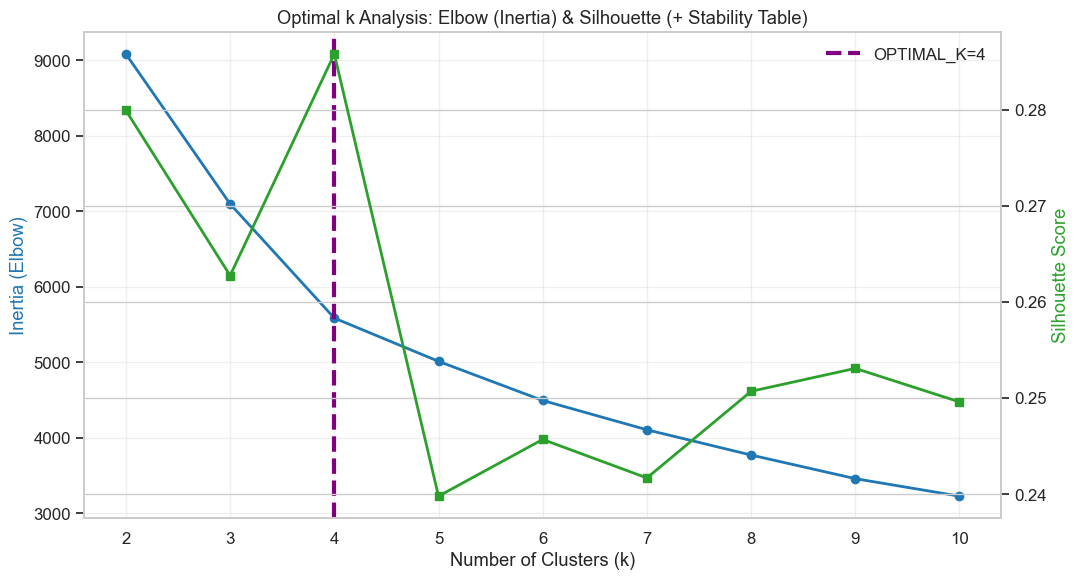

In [5]:
# ----------------------------------------------------------------------
# 6 Plots: Elbow (inertia) + Silhouette (with OPTIMAL_K marker)
# ----------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(11, 6))
color_blue = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color=color_blue)
ax1.plot(df_k["k"], df_k["inertia"], marker='o', color=color_blue, linewidth=2)
ax1.axvline(x=OPTIMAL_K, linestyle='--', color='purple', linewidth=3, label=f'OPTIMAL_K={OPTIMAL_K}')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color_green = 'tab:green'
ax2.set_ylabel('Silhouette Score', color=color_green)
ax2.plot(df_k["k"], df_k["silhouette"], marker='s', color=color_green, linewidth=2)

plt.title('Optimal k Analysis: Elbow (Inertia) & Silhouette (+ Stability Table)')
ax1.legend(loc='best')
plt.tight_layout()
plt.show()

## 7. Final Clustering Model (K-Means)

Using the selected **OPTIMAL_K**, we fit a final K-Means model and assign a cluster label to each route.

### Output produced
A new column is added to the route-level dataset:

- `cluster` → integer label indicating which group the route belongs to

### Why we keep the route-level table
Because the goal is operational insights at the route level, we preserve:
- origin/destination airports,
- route-level metrics,
- and the assigned cluster

This makes the results directly usable for reporting and decision-making.

In [6]:
# ==============================================================================
# 7. CLUSTERING MODEL (K-Means)
# ==============================================================================
# OPTIMAL_K is selected automatically in Section 3 (Silhouette + Stability).
print(f"Applying K-Means with OPTIMAL_K={OPTIMAL_K}...")
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_routes['cluster'] = kmeans_final.fit_predict(X_scaled)


Applying K-Means with OPTIMAL_K=4...


## 8. Cluster Profiling (Heatmap of Standardized Means)

To interpret what each cluster “means”, we compute the **mean** of key variables per cluster:

- `avg_delay`
- `avg_distance`
- `flight_count`

Then we transform them into **Z-scores** (standardized relative to global mean/std) and plot a heatmap.

### Why this heatmap is useful
It quickly answers questions like:
- Which clusters have **higher-than-average delays**?
- Which clusters represent **long-haul** routes?
- Which clusters contain **high-frequency** routes?

Z-scores make different units comparable on the same visual scale.

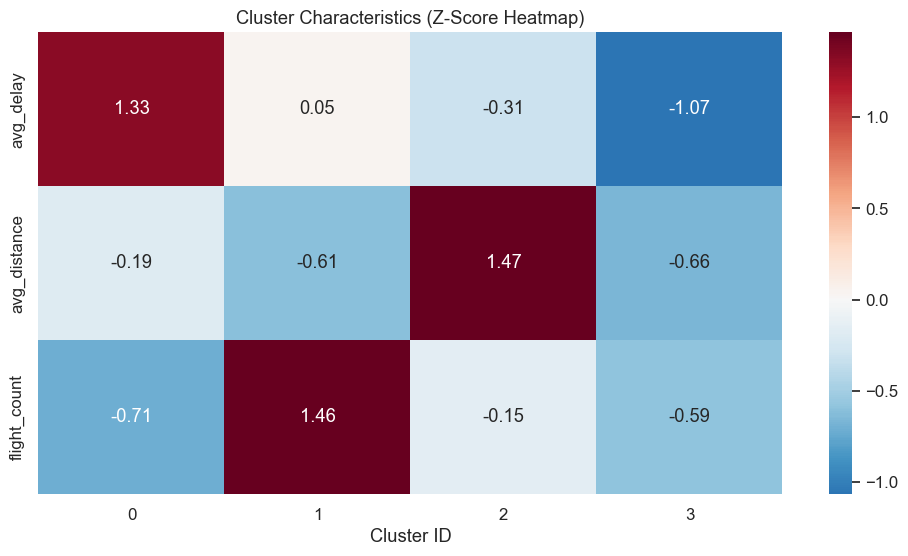

In [7]:
# ==============================================================================
# 8. VISUALIZATION & INTERPRETATION
# ==============================================================================

# Calculate mean values for original features per cluster
cluster_profile = df_routes.groupby('cluster')[['avg_delay', 'avg_distance', 'flight_count']].mean()

# Plot
plt.figure(figsize=(12, 6))
# Normalize for visualization comparison
cluster_profile_norm = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
sns.heatmap(cluster_profile_norm.T, cmap='RdBu_r', center=0, annot=True, fmt='.2f')
plt.title('Cluster Characteristics (Z-Score Heatmap)')
plt.xlabel('Cluster ID')
plt.show()

## 9. Scatter Visualizations (2D + 3D) with Centroids

We visualize clusters in the original feature space to check separation and interpretability.

### 9.1 Distance vs Delay (bubble size = frequency)
This plot highlights:
- how delay varies across distances,
- whether long-haul routes form distinct groups,
- and which routes are high-volume (larger bubbles)

### 9.2 Distance vs Frequency
This plot helps identify:
- core high-frequency corridors,
- long-haul routes with lower frequency,
- and how distance relates to demand patterns

### 9.3 3D Overview (Distance × Delay × Frequency)
A 3D plot is harder to read precisely, but useful as a **sanity check**:
- do clusters separate in the full feature space?
- are there obvious overlaps or extreme outliers?

### Centroids (cluster centers)
Because K-Means is trained on scaled features (`StandardScaler`), we **inverse-transform** cluster centers back to original units for interpretation.

**Important detail:**
One feature is `log_frequency`, so after inverse-scaling we apply `exp()` to convert it back to an approximate `flight_count` scale for plotting centroids.

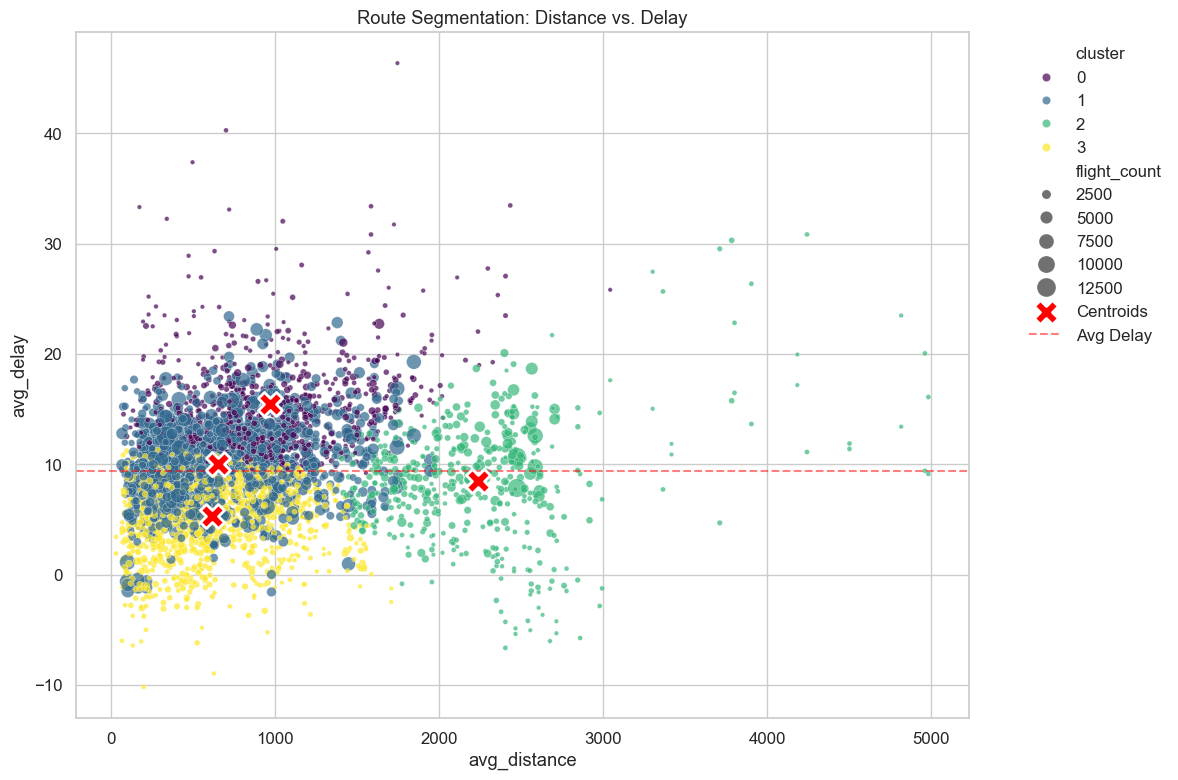

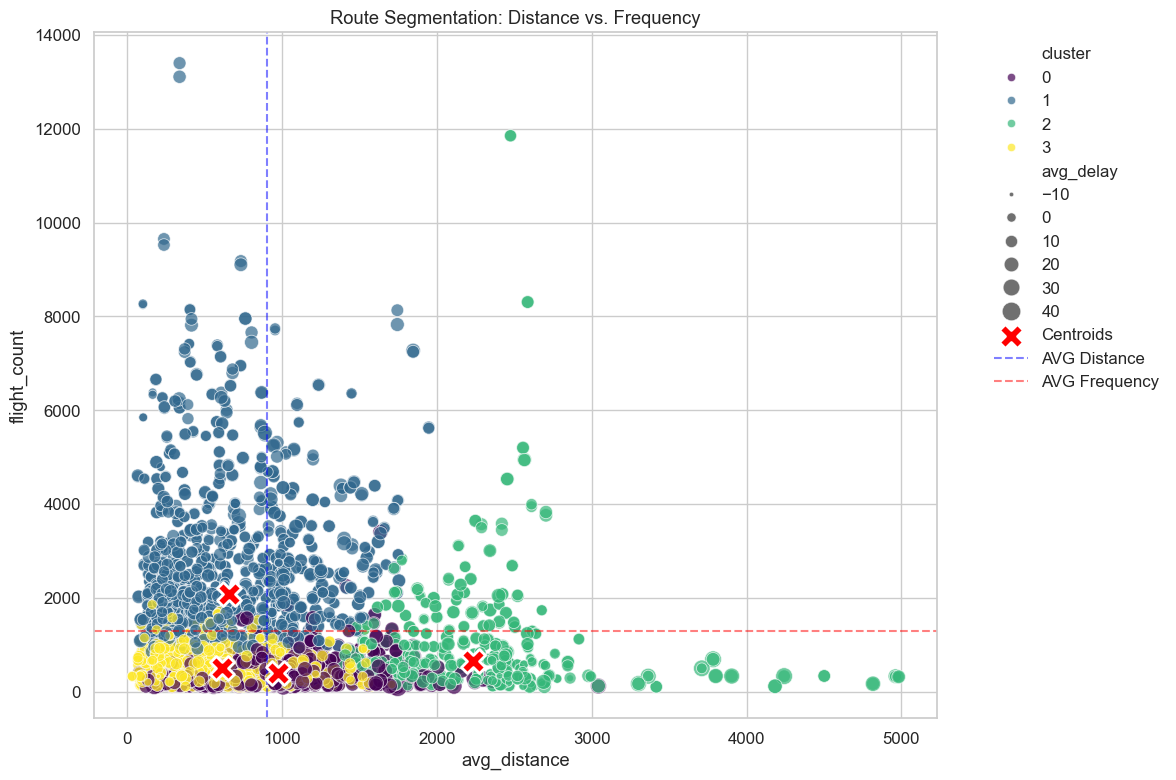

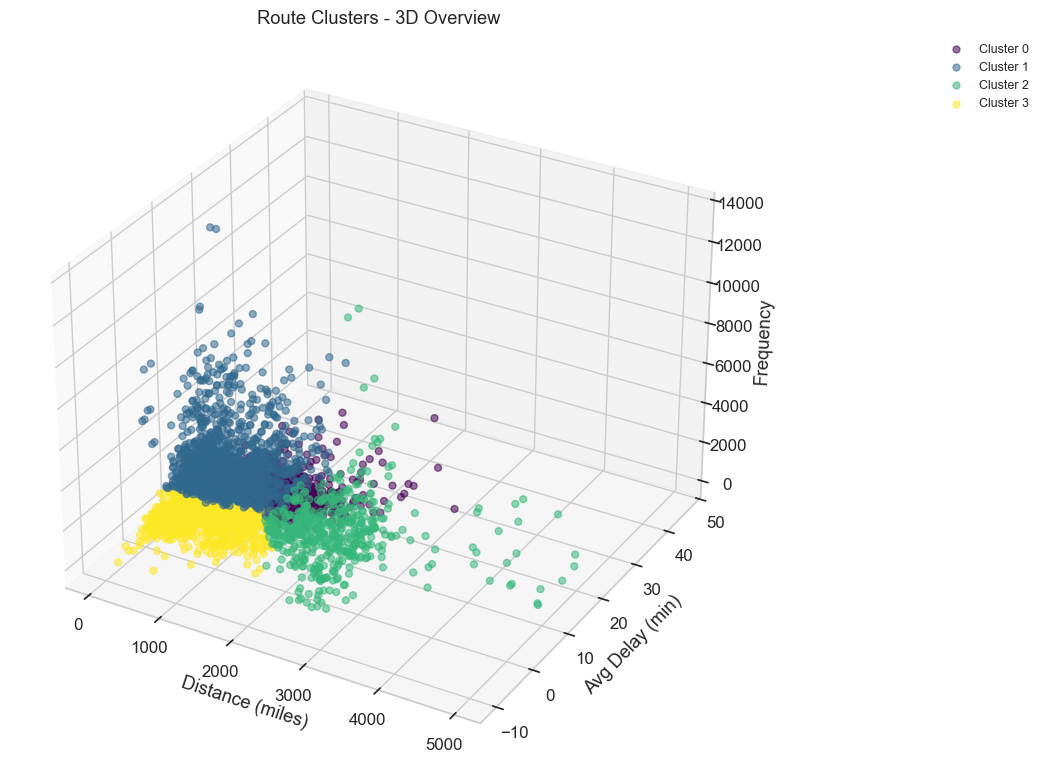

In [8]:
# ==============================================================================
# 9 Scatter Plot: Distance vs Delay (Size = Frequency) with Centroids
# ==============================================================================
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_routes, x='avg_distance', y='avg_delay',
                hue='cluster', palette='viridis', size='flight_count',
                sizes=(10, 200), alpha=0.7)

# It retrieves centroids and converts them to the original scale.
# features = ['avg_delay', 'avg_distance', 'log_frequency']
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Plots the centroids (indices: 0=avg_delay, 1=avg_distance, 2=log_frequency)
plt.scatter(
    centroids_original[:, 1],
    centroids_original[:, 0],
    c='red',
    marker='X',
    s=300,
    edgecolors='white',
    linewidths=2,
    label='Centroids',
    zorder=10
)

plt.title('Route Segmentation: Distance vs. Delay')
plt.axhline(y=df_routes['avg_delay'].mean(), color='red', linestyle='--', alpha=0.5, label='Avg Delay')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_routes,
    x="avg_distance",
    y="flight_count",
    hue="cluster",
    palette="viridis",
    size="avg_delay",
    sizes=(10, 200),
    alpha=0.7
)

# Retrieve centroids and convert them to the original scale
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Centroid indices: 0=avg_delay, 1=avg_distance, 2=log_frequency
centroid_distance = centroids_original[:, 1]
centroid_frequency = np.exp(centroids_original[:, 2])  # log -> original (approx)

# Plot centroids on (distance, frequency)
plt.scatter(
    centroid_distance,
    centroid_frequency,
    c="red",
    marker="X",
    s=300,
    edgecolors="white",
    linewidths=2,
    label="Centroids",
    zorder=10
)

plt.title("Route Segmentation: Distance vs. Frequency")
plt.axvline(x=df_routes['avg_distance'].mean(), color='blue', linestyle='--', alpha=0.5, label='AVG Distance')
plt.axhline(y=df_routes['flight_count'].mean(), color='red', linestyle='--', alpha=0.5, label='AVG Frequency')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# 3D Scatter - Distance x Delay x Frequency + Centroids (with legend like 2D)
# ----------------------------------------------------------------------
# Notes:
# - 3D plots are harder to read, but good for a quick holistic sanity check.
# - Color encodes cluster; points include all routes;
# ----------------------------------------------------------------------

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Build a stable color map for clusters
clusters = sorted(df_routes["cluster"].unique())
cmap = plt.cm.get_cmap("viridis", len(clusters))

# Plot points per cluster so we can get a proper legend
for i, cluster_id in enumerate(clusters):
    mask = df_routes["cluster"] == cluster_id
    ax.scatter(
        df_routes.loc[mask, "avg_distance"],
        df_routes.loc[mask, "avg_delay"],
        df_routes.loc[mask, "flight_count"],
        color=cmap(i),
        alpha=0.55,
        s=25,
        label=f"Cluster {cluster_id}"
    )

# Plot centroids
"""ax.scatter(
    centroid_distance,
    centroids_original[:, 0],  # centroid_delay
    centroid_frequency,
    c="red",
    marker="X",
    s=250,
    edgecolors="white",
    linewidths=2,
    label="Centroids",
    depthshade=False
)"""

ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Avg Delay (min)")
ax.set_zlabel("Frequency")
ax.set_title("Route Clusters - 3D Overview")

# Legend outside, similar to 2D plots
ax.legend(bbox_to_anchor=(1.25, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


## 10. Executive Summary and Export

Finally, we generate a per-cluster “business reporting” summary, including:

- number of routes in each cluster
- average delay, distance, and frequency
- representative examples (top routes by flight volume)

### Heuristic cluster labeling
We assign a human-readable interpretation using simple rules based on cluster averages, such as:

- **LONG HAUL / TRANSCONTINENTAL**
- **HIGH FREQUENCY / SHUTTLE ROUTES**
- **PROBLEM ROUTES (HIGH DELAY)**
- **REGIONAL / LOW DENSITY**

These labels are meant as a **first-pass interpretation** and should be refined based on domain knowledge and stakeholder needs.

### Export
We export the final route-level dataset (with cluster labels) to:

- `data/clustered_routes.csv`

This file can be used downstream for dashboards, reporting, or targeted operational investigation.

In [9]:
# ==============================================================================
# 10. BUSINESS REPORTING (The "Hybrid Strategy" Summary)
# ==============================================================================
print("\n" + "="*80)
print("EXECUTIVE SUMMARY OF FLIGHT ROUTE CLUSTERS")
print("="*80)

# Generate detailed text report
for cluster_id in sorted(df_routes['cluster'].unique()):
    c_data = df_routes[df_routes['cluster'] == cluster_id]

    # Representative Routes (Top 3 by volume)
    top_routes = c_data.nlargest(3, 'flight_count')
    examples = [f"{row['ORIGIN_AIRPORT']}->{row['DESTINATION_AIRPORT']}" for _, row in top_routes.iterrows()]

    print(f"\n CLUSTER {cluster_id}: {len(c_data):,} routes")
    print(f"   • Avg Delay:     {c_data['avg_delay'].mean():5.1f} min")
    print(f"   • Avg Distance:  {c_data['avg_distance'].mean():5.0f} miles")
    print(f"   • Avg Frequency: {c_data['flight_count'].mean():5.0f} flights/year")
    print(f"   • Key Examples:  {', '.join(examples)}")

    # Automated Interpretation Logic
    if c_data['avg_distance'].mean() > 2000:
        label = "LONG HAUL / TRANSCONTINENTAL"
    elif c_data['flight_count'].mean() > 3000:
        label = "HIGH FREQUENCY / SHUTTLE ROUTES"
    elif c_data['avg_delay'].mean() > 15:
        label = "PROBLEM ROUTES (HIGH DELAY)"
    else:
        label = "REGIONAL / LOW DENSITY"
    print(f" INTERPRETATION: {label}")

print("\n" + "="*80)

# Export results
df_routes.to_csv('data/clustered_routes.csv', index=False)
print("Results exported to 'clustered_routes.csv'")


EXECUTIVE SUMMARY OF FLIGHT ROUTE CLUSTERS

 CLUSTER 0: 782 routes
   • Avg Delay:      15.4 min
   • Avg Distance:    972 miles
   • Avg Frequency:   468 flights/year
   • Key Examples:  IAH->SFO, IAH->LGA, PBI->JFK
 INTERPRETATION: PROBLEM ROUTES (HIGH DELAY)

 CLUSTER 1: 1,477 routes
   • Avg Delay:      10.0 min
   • Avg Distance:    654 miles
   • Avg Frequency:  2432 flights/year
   • Key Examples:  SFO->LAX, LAX->SFO, LAS->LAX
 INTERPRETATION: REGIONAL / LOW DENSITY

 CLUSTER 2: 507 routes
   • Avg Delay:       8.5 min
   • Avg Distance:   2235 miles
   • Avg Frequency:   975 flights/year
   • Key Examples:  JFK->LAX, LAX->JFK, SFO->JFK
 INTERPRETATION: LONG HAUL / TRANSCONTINENTAL

 CLUSTER 3: 1,301 routes
   • Avg Delay:       5.3 min
   • Avg Distance:    613 miles
   • Avg Frequency:   583 flights/year
   • Key Examples:  YUM->PHX, RSW->CLT, SJC->SLC
 INTERPRETATION: REGIONAL / LOW DENSITY

Results exported to 'clustered_routes.csv'
